In [1]:
import os
import io
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Global matplotlib/ACL baseline styles
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'figure.dpi': 300
})

TEST_SET_SIZES = {
    'VRDU': 500,
    'Kleister NDA': 337
}

def parse_standard_report(file_path):
    """Parses a single standard run report CSV and returns extracted metrics."""
    df_temp = pd.read_csv(file_path)
    model_name = df_temp['model_name'].iloc[0] if 'model_name' in df_temp.columns else "unknown"
    batch_size = df_temp['batch_size'].iloc[0] if 'batch_size' in df_temp.columns else 1
    backend = df_temp['backend'].iloc[0] if 'backend' in df_temp.columns else "default"
    energy = df_temp['total_energy_wh'].iloc[0] if 'total_energy_wh' in df_temp.columns else 0.0

    # Extract Quantization from folder path
    is_quant = 'quant' in file_path.lower() and 'noquant' not in file_path.lower()

    # Exact Match Evaluation
    if 'avg_calculated_field_em' in df_temp.columns:
        exact_match = df_temp['avg_calculated_field_em'].iloc[0] * 100
    else:
        exact_match = df_temp['avg_field_em'].iloc[0] * 100 if 'avg_field_em' in df_temp.columns else 0.0

    # Fuzzy Match Evaluation[cite: 1]
    fuzzy_match = df_temp['avg_calculated_fuzzy_score'].iloc[0] * 100 if 'avg_calculated_fuzzy_score' in df_temp.columns else 0.0

    # F1 Score Evaluation[cite: 1]
    if 'avg_calculated_document_f1' in df_temp.columns:
        f1_score = df_temp['avg_calculated_document_f1'].iloc[0] * 100
    else:
        f1_score = df_temp['avg_field_f1'].iloc[0] * 100 if 'avg_field_f1' in df_temp.columns else 0.0

    dataset = "VRDU" if "vrdu" in file_path else "Kleister NDA"
    modality = "Vision" if "vrdu_vision" in file_path or "kleister_nda_vl" in file_path else "Text-Only"

    if "deepseek" in file_path: task = "deepseek"
    elif "docling" in file_path: task = "docling"
    elif "tesseract" in file_path: task = "tesseract"
    elif modality == "Vision": task = "vision"
    elif "vrdu_text_only" in file_path: task = "default"
    else: task = df_temp['task'].iloc[0] if 'task' in df_temp.columns else "default"

    return {
        'Dataset': dataset, 'Model': model_name, 'Batch_Size': batch_size, 'Quantized': is_quant,
        'Exact_Match': exact_match, 'Accuracy': exact_match, 'Fuzzy_Match': fuzzy_match, 'F1_Score': f1_score,
        'Energy_Wh': energy, 'Modality': modality, 'Task': task, 'Backend': backend
    }

# Note: Ensure you apply the same 'Quantized': False logic to the load_all_data() NuExtract and Arctic-Tilt dictionaries[cite: 1].
# Run your master pipeline here to generate df_all.

In [2]:
def load_cleaned_energy_report(filepath):
    """Reads the CSV, adds a batch_size column, and aligns all rows[cite: 1]."""
    if not os.path.exists(filepath):
        return pd.DataFrame()

    with open(filepath, 'r') as file:
        lines = file.readlines()

    if not lines:
        return pd.DataFrame()

    # 1. Update the header to include 'batch_size' right after 'dataset_name'[cite: 1]
    header = lines[0].strip('\n').split(',')
    if header[1] != 'batch_size':
        header.insert(1, 'batch_size')

    cleaned_lines = [','.join(header) + '\n']

    # 2. Process the data rows[cite: 1]
    for line in lines[1:]:
        parts = line.strip('\n').split(',')

        # If the row has 39 columns, it's missing the batch size.[cite: 1]
        # We insert a default batch size of '1' at index 1.[cite: 1]
        if len(parts) == 39:
            parts.insert(1, '1')
        # If it has 40 columns, the batch size is already sitting at index 1[cite: 1]
        elif len(parts) > 40:
            parts = parts[:40]

        cleaned_lines.append(','.join(parts) + '\n')

    # Feed the uniformly formatted text directly into pandas[cite: 1]
    return pd.read_csv(io.StringIO(''.join(cleaned_lines)))

def load_all_data():
    """Unifies standard reports, Arctic results, and standalone benchmarks into one DataFrame[cite: 1]."""
    data_list = []

    # 1. Parse Standard Run Reports[cite: 1]
    standard_paths = [
        "../vrdu_noquant/run_report/*.csv",
        "../vrdu_quant/run_report/*.csv",
        "../vrdu_vision_noquant/run_report/*.csv",
        "../vrdu_vision_quant/run_report/*.csv",
        "../kleister_nda_noquant/run_report/*.csv",
        "../kleister_nda_quant/run_report/*.csv",
        "../kleister_nda_vl_noquant/run_report/*.csv",
        "../kleister_nda_vl_quant/run_report/*.csv",
    ]
    for path in standard_paths:
        for file in glob.glob(path):
            try:
                data_list.append(parse_standard_report(file))
            except Exception as e:
                print(f"Error reading standard file {file}: {e}")

    # 2. Parse Arctic Evaluation Logs & New Inference Energy Report[cite: 1]
    arctic_dir = "../arctic_results/"
    inference_energy_path = "../arctic_results/inference_energy_report.csv"

    if os.path.exists(arctic_dir):
        try:
            energy_df = pd.DataFrame()
            if os.path.exists(inference_energy_path):
                energy_df = load_cleaned_energy_report(inference_energy_path)

            for file in glob.glob(os.path.join(arctic_dir, "evaluation_*.csv")):
                filename = os.path.basename(file)
                df_eval = pd.read_csv(file)

                # Dynamically find the correct Metric Key and Score columns[cite: 1]
                metric_col = 'Metric / Entity Key' if 'Metric / Entity Key' in df_eval.columns else 'Entity Key / Metric'
                score_col = 'F1 Score' if 'F1 Score' in df_eval.columns else 'Fuzzy Match'

                # Exact Match Extraction[cite: 1]
                em_row = df_eval[df_eval[metric_col].isin(['Average Field EM', 'avg_calculated_field_em']) |
                                 df_eval[metric_col].str.contains('Field EM|Exact Match|field_em', case=False, na=False)]
                em_row = em_row[~em_row[metric_col].str.contains('Subset', case=False, na=False)]
                exact_match = (em_row[score_col].dropna().iloc[0] * 100) if not em_row.empty else 0.0

                # Fuzzy & F1 Extraction[cite: 1]
                fuzzy_row = df_eval[df_eval[metric_col].str.contains('Fuzzy|fuzzy_score', case=False, na=False)]
                fuzzy_match = (fuzzy_row[score_col].dropna().iloc[0] * 100) if not fuzzy_row.empty else 0.0

                f1_row = df_eval[df_eval[metric_col].str.contains('Document F1|Field F1|document_f1', case=False, na=False)]
                f1_score = (f1_row[score_col].dropna().iloc[0] * 100) if not f1_row.empty else 0.0

                # Determine standard parameters based on filename[cite: 1]
                dataset = "VRDU" if "vrdu" in filename else "Kleister NDA"
                search_ds = "vrdu" if "vrdu" in filename else "kleister"

                if "docling" in filename:
                    task, search_task = "docling", "docling"
                elif "tesseract" in filename:
                    task, search_task = "tesseract", "tesseract"
                elif "deepseek" in filename:
                    task, search_task = "deepseek", "deepseek"
                elif "baseline" in filename:
                    task, search_task = "default", "default"
                else:
                    task = "default"
                    search_task = "registration" if "vrdu" in filename else "ready"

                # Energy Matching Logic[cite: 1]
                energy_wh = 0.0
                if not energy_df.empty and 'dataset_name' in energy_df.columns:
                    mask = (
                        energy_df['dataset_name'].str.contains(search_ds, case=False, na=False) &
                        energy_df['dataset_name'].str.contains(search_task, case=False, na=False)
                    )
                    energy_match = energy_df[mask]

                    if not energy_match.empty:
                        energy_wh = energy_match['energy_consumed'].iloc[0] * 1000

                # Append for both BS configurations[cite: 1]
                # Explicitly setting Quantized to False for standalone Arctic runs
                for bs_config in [1, 10]:
                    data_list.append({
                        'Dataset': dataset, 'Model': 'Arctic-Tilt', 'Batch_Size': bs_config, 'Quantized': False,
                        'Exact_Match': exact_match, 'Accuracy': exact_match, 'Fuzzy_Match': fuzzy_match, 'F1_Score': f1_score,
                        'Energy_Wh': energy_wh, 'Modality': 'Text-Only', 'Task': task, 'Backend': 'vllm'
                    })
        except Exception as e:
            print(f"Error parsing arctic_results: {e}")

    # 3. Parse Standalone NuExtract Benchmark Results[cite: 1]
    nuextract_configs = [
        {'path': '../benchmark/nuextract_vrdu/nuextract_vrdu_metrics.csv', 'dataset': 'VRDU'},
        {'path': '../benchmark/nuextract_kleister/kleister_standalone_metrics_output.csv', 'dataset': 'Kleister NDA'}
    ]
    for cfg in nuextract_configs:
        if os.path.exists(cfg['path']):
            try:
                df_nu = pd.read_csv(cfg['path'])

                exact_match = df_nu['avg_calculated_field_em'].iloc[0] * 100 if 'avg_calculated_field_em' in df_nu.columns else df_nu['avg_field_em'].iloc[0] * 100
                f1_score = df_nu['avg_calculated_document_f1'].iloc[0] * 100 if 'avg_calculated_document_f1' in df_nu.columns else df_nu.get('avg_field_f1', pd.Series([0.0])).iloc[0] * 100
                fuzzy_match = df_nu['avg_calculated_fuzzy_score'].iloc[0] * 100 if 'avg_calculated_fuzzy_score' in df_nu.columns else 0.0

                energy = df_nu['total_energy_wh'].iloc[0]

                # Explicitly setting Quantized to False for NuExtract standalone[cite: 1]
                data_list.append({
                    'Model': 'NuExtract-2.0-4B', 'Dataset': cfg['dataset'], 'Modality': 'Vision', 'Quantized': False,
                    'Exact_Match': exact_match, 'Accuracy': exact_match, 'Fuzzy_Match': fuzzy_match, 'F1_Score': f1_score,
                    'Energy_Wh': energy, 'Batch_Size': 1, 'Task': 'vision', 'Backend': 'default'
                })
            except Exception as e:
                print(f"Error loading NuExtract path {cfg['path']}: {e}")

    df_all = pd.DataFrame(data_list)
    if not df_all.empty:
        df_all['Backend'] = df_all['Backend'].replace('vllm-vl', 'vllm')
        df_all['Batch_Size'] = pd.to_numeric(df_all['Batch_Size']).fillna(1)

        task_mapping = {
            'vrdu_default': 'Baseline (Dataset)', 'default': 'Baseline (Dataset)',
            'vrdu_docling': 'Docling', 'docling': 'Docling',
            'vrdu_deepseek': 'DeepSeek OCR', 'deepseek': 'DeepSeek OCR'
        }
        df_all['Task_Clean'] = df_all['Task'].map(lambda x: task_mapping.get(x, x))

    return df_all

def integrate_vrdu_batch_energy(df_master, energy_csv_path):
    """Appends missing Arctic-Tilt batch size energy data exclusively for VRDU plotting[cite: 1]."""
    energy_df = load_cleaned_energy_report(energy_csv_path)
    if energy_df.empty:
        return df_master

    vrdu_energy = energy_df[energy_df['dataset_name'].str.contains('vrdu', case=False, na=False)].copy()
    if vrdu_energy.empty:
        return df_master

    vrdu_energy['Batch_Size'] = pd.to_numeric(vrdu_energy['batch_size'])
    vrdu_energy['Energy_Wh'] = vrdu_energy['energy_consumed'] * 1000
    vrdu_energy['Dataset'] = 'VRDU'
    vrdu_energy['Model'] = 'Arctic-Tilt'
    vrdu_energy['Modality'] = 'Text-Only'
    vrdu_energy['Backend'] = 'vllm'

    # Adding Quantized flag to integrated data
    vrdu_energy['Quantized'] = False

    existing_bs = df_master[(df_master['Dataset'] == 'VRDU') & (df_master['Model'] == 'Arctic-Tilt')]['Batch_Size'].unique()
    new_energy_data = vrdu_energy[~vrdu_energy['Batch_Size'].isin(existing_bs)]

    # Include Quantized in cols_to_keep
    cols_to_keep = ['Dataset', 'Model', 'Batch_Size', 'Energy_Wh', 'Modality', 'Backend', 'Quantized']
    return pd.concat([df_master, new_energy_data[cols_to_keep]], ignore_index=True)

# Execute Master Data Pipeline
df_all = load_all_data()
df_all = integrate_vrdu_batch_energy(df_all, "../arctic_results/inference_energy_report.csv")
print(f"Successfully loaded master dataframe with {len(df_all)} total pipeline entries.")

Successfully loaded master dataframe with 404 total pipeline entries.


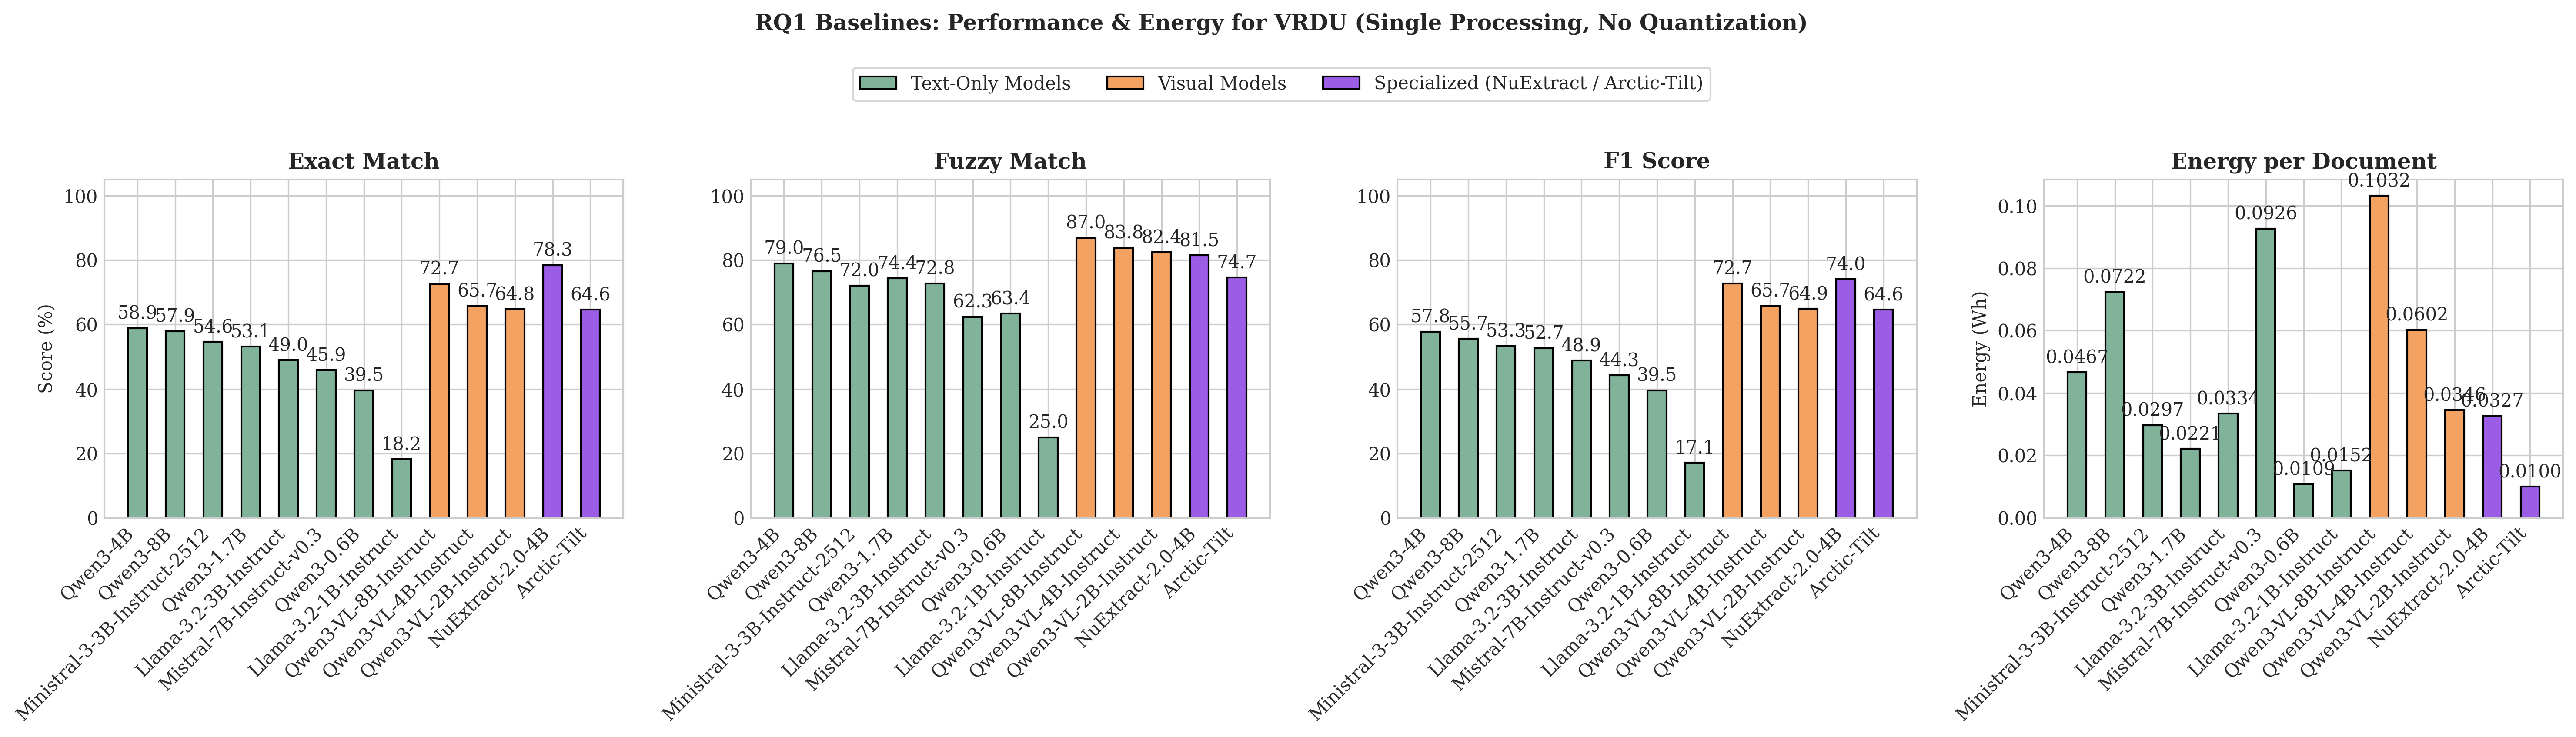

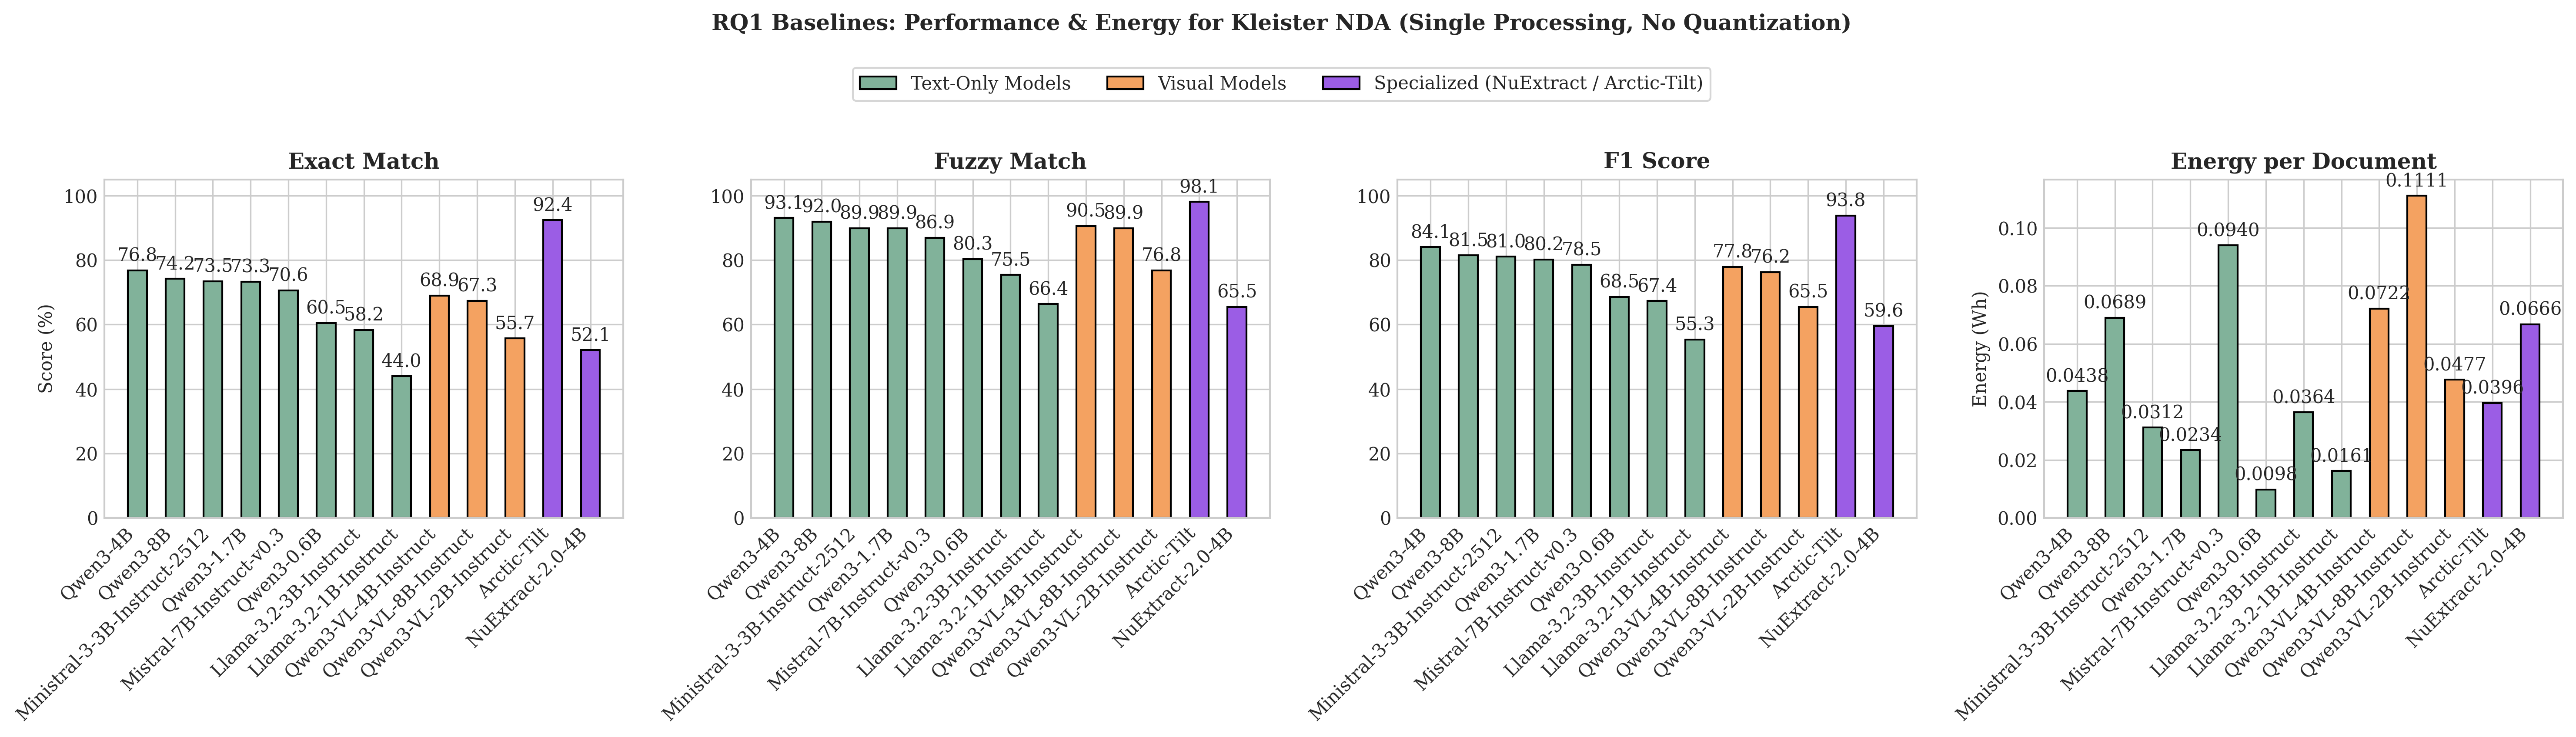

In [3]:
from matplotlib.patches import Patch
import numpy as np
import matplotlib.pyplot as plt

# RQ1 Data Filtering
df_rq1 = df_all[
    (df_all['Batch_Size'] == 1) &
    (df_all['Quantized'] == False) &
    (
        (df_all['Modality'] == 'Vision') |
        ((df_all['Modality'] == 'Text-Only') & (df_all['Task'] == 'tesseract'))
    )
].copy()

# Calculate Energy per Document
df_rq1['Energy_per_Doc_Wh'] = df_rq1.apply(
    lambda row: row['Energy_Wh'] / TEST_SET_SIZES.get(row['Dataset'], 1), axis=1
)

datasets = ['VRDU', 'Kleister NDA']
metrics = ['Exact_Match', 'Fuzzy_Match', 'F1_Score']

# Helper function to assign colors and a sorting index
def get_color_and_sort_index(row):
    model_name = str(row['Model']).lower()
    if 'nuextract' in model_name or 'arctic-tilt' in model_name:
        return pd.Series(['#9b5de5', 3])  # Purple for specialized, sorted last
    elif row['Modality'] == 'Vision':
        return pd.Series(['#f4a261', 2])  # Orange for visual, sorted second
    elif row['Modality'] == 'Text-Only':
        return pd.Series(['#81b29a', 1])  # Green for text-only, sorted first
    return pd.Series(['gray', 4])

for dataset in datasets:
    df_ds = df_rq1[df_rq1['Dataset'] == dataset].copy()
    if df_ds.empty: continue

    # Apply the helper function to create Color and Sort columns
    df_ds[['Color', 'Category_Sort_Index']] = df_ds.apply(get_color_and_sort_index, axis=1)

    # Sort by Category Group first, then by Exact_Match descending
    df_ds = df_ds.sort_values(by=['Category_Sort_Index', 'Exact_Match'], ascending=[True, False])

    # Extract the sorted colors into a list for plotting
    bar_colors = df_ds['Color'].tolist()

    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)
    x = np.arange(len(df_ds['Model']))
    width = 0.5

    # Plot Accuracy Metrics
    for i, metric in enumerate(metrics):
        ax = axes[i]
        rects = ax.bar(x, df_ds[metric], width, color=bar_colors, edgecolor='black')
        for rect in rects:
            height = rect.get_height()
            if height > 0:
                ax.annotate(f'{height:.1f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
        ax.set_title(metric.replace('_', ' '), fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(df_ds['Model'], rotation=45, ha='right')
        ax.set_ylim(0, 105)
        if i == 0: ax.set_ylabel('Score (%)')

    # Plot Energy Consumption
    ax_e = axes[3]
    rects_e = ax_e.bar(x, df_ds['Energy_per_Doc_Wh'], width, color=bar_colors, edgecolor='black')
    for rect in rects_e:
        height = rect.get_height()
        if height > 0:
            ax_e.annotate(f'{height:.4f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
    ax_e.set_title('Energy per Document', fontweight='bold')
    ax_e.set_xticks(x)
    ax_e.set_xticklabels(df_ds['Model'], rotation=45, ha='right')
    ax_e.set_ylabel('Energy (Wh)')

    # Add custom legend for color mappings
    legend_elements = [
        Patch(facecolor='#81b29a', edgecolor='black', label='Text-Only Models'),
        Patch(facecolor='#f4a261', edgecolor='black', label='Visual Models'),
        Patch(facecolor='#9b5de5', edgecolor='black', label='Specialized (NuExtract / Arctic-Tilt)')
    ]
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, frameon=True)

    # Adjusted title Y-position to accommodate the new legend
    plt.suptitle(f'RQ1 Baselines: Performance & Energy for {dataset} (Single Processing, No Quantization)', y=1.12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'rq1_baselines_{dataset.lower().replace(" ", "_")}.pdf', bbox_inches='tight')
    plt.show()

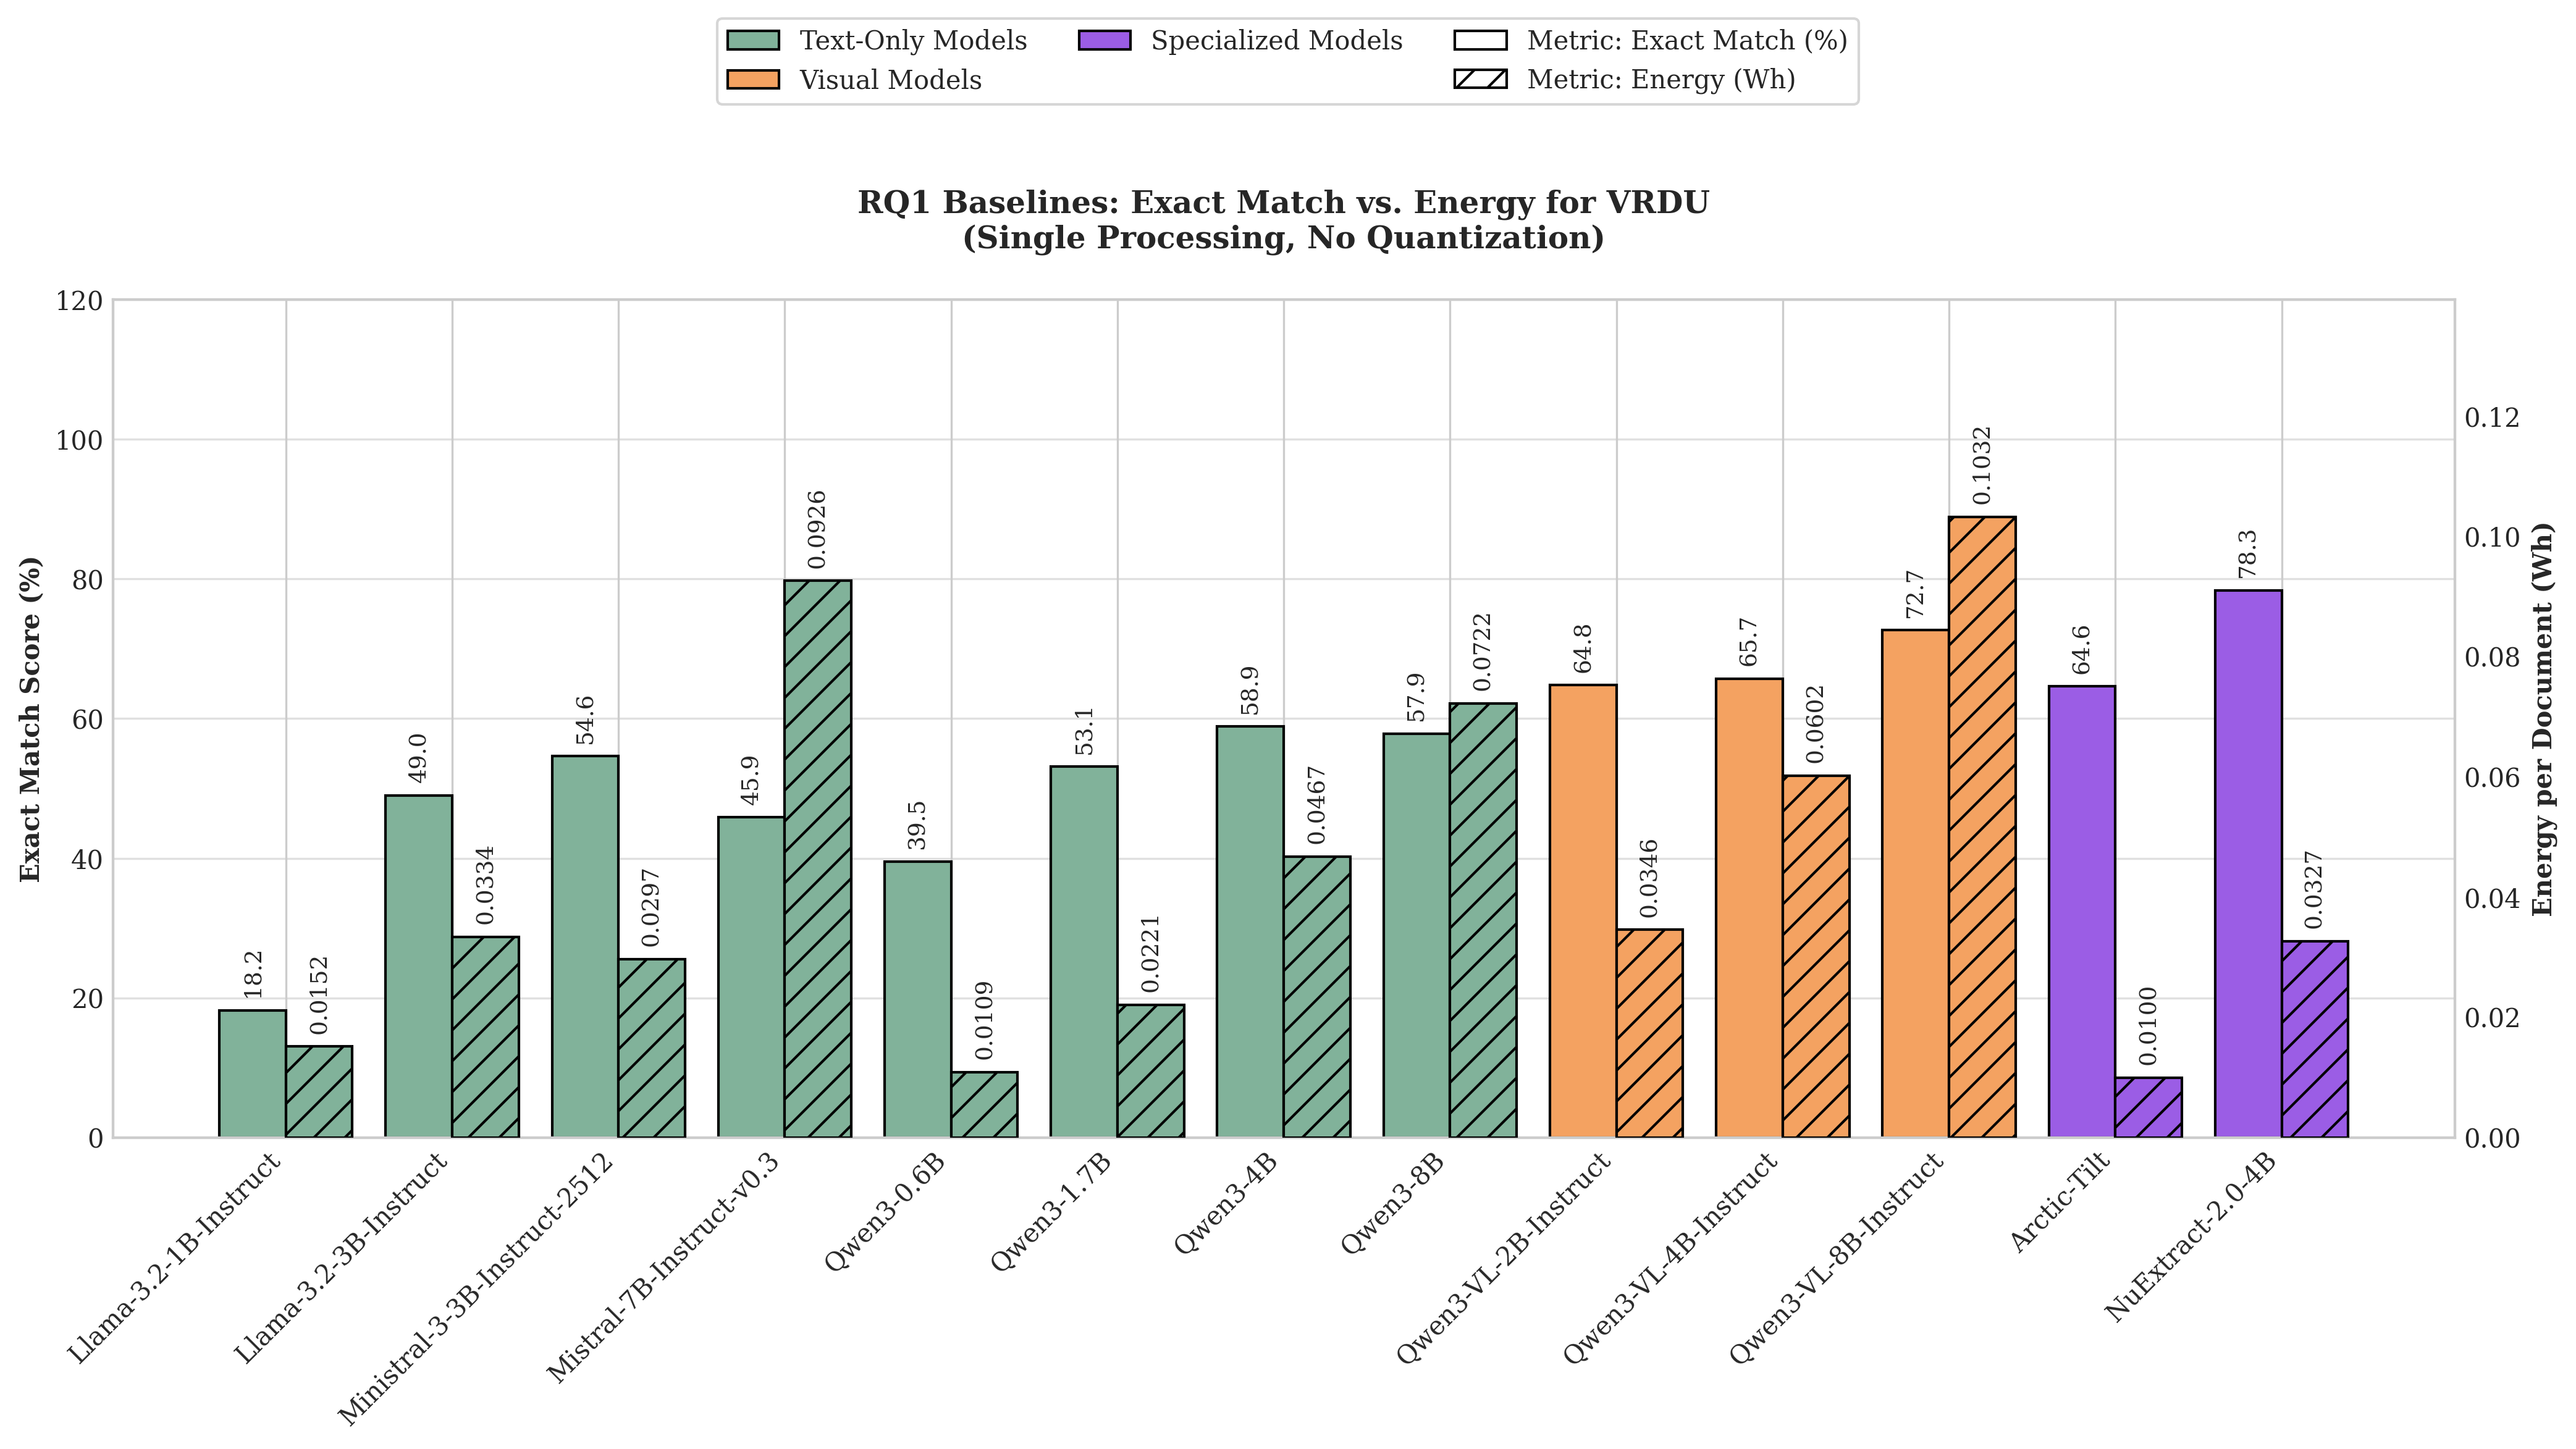

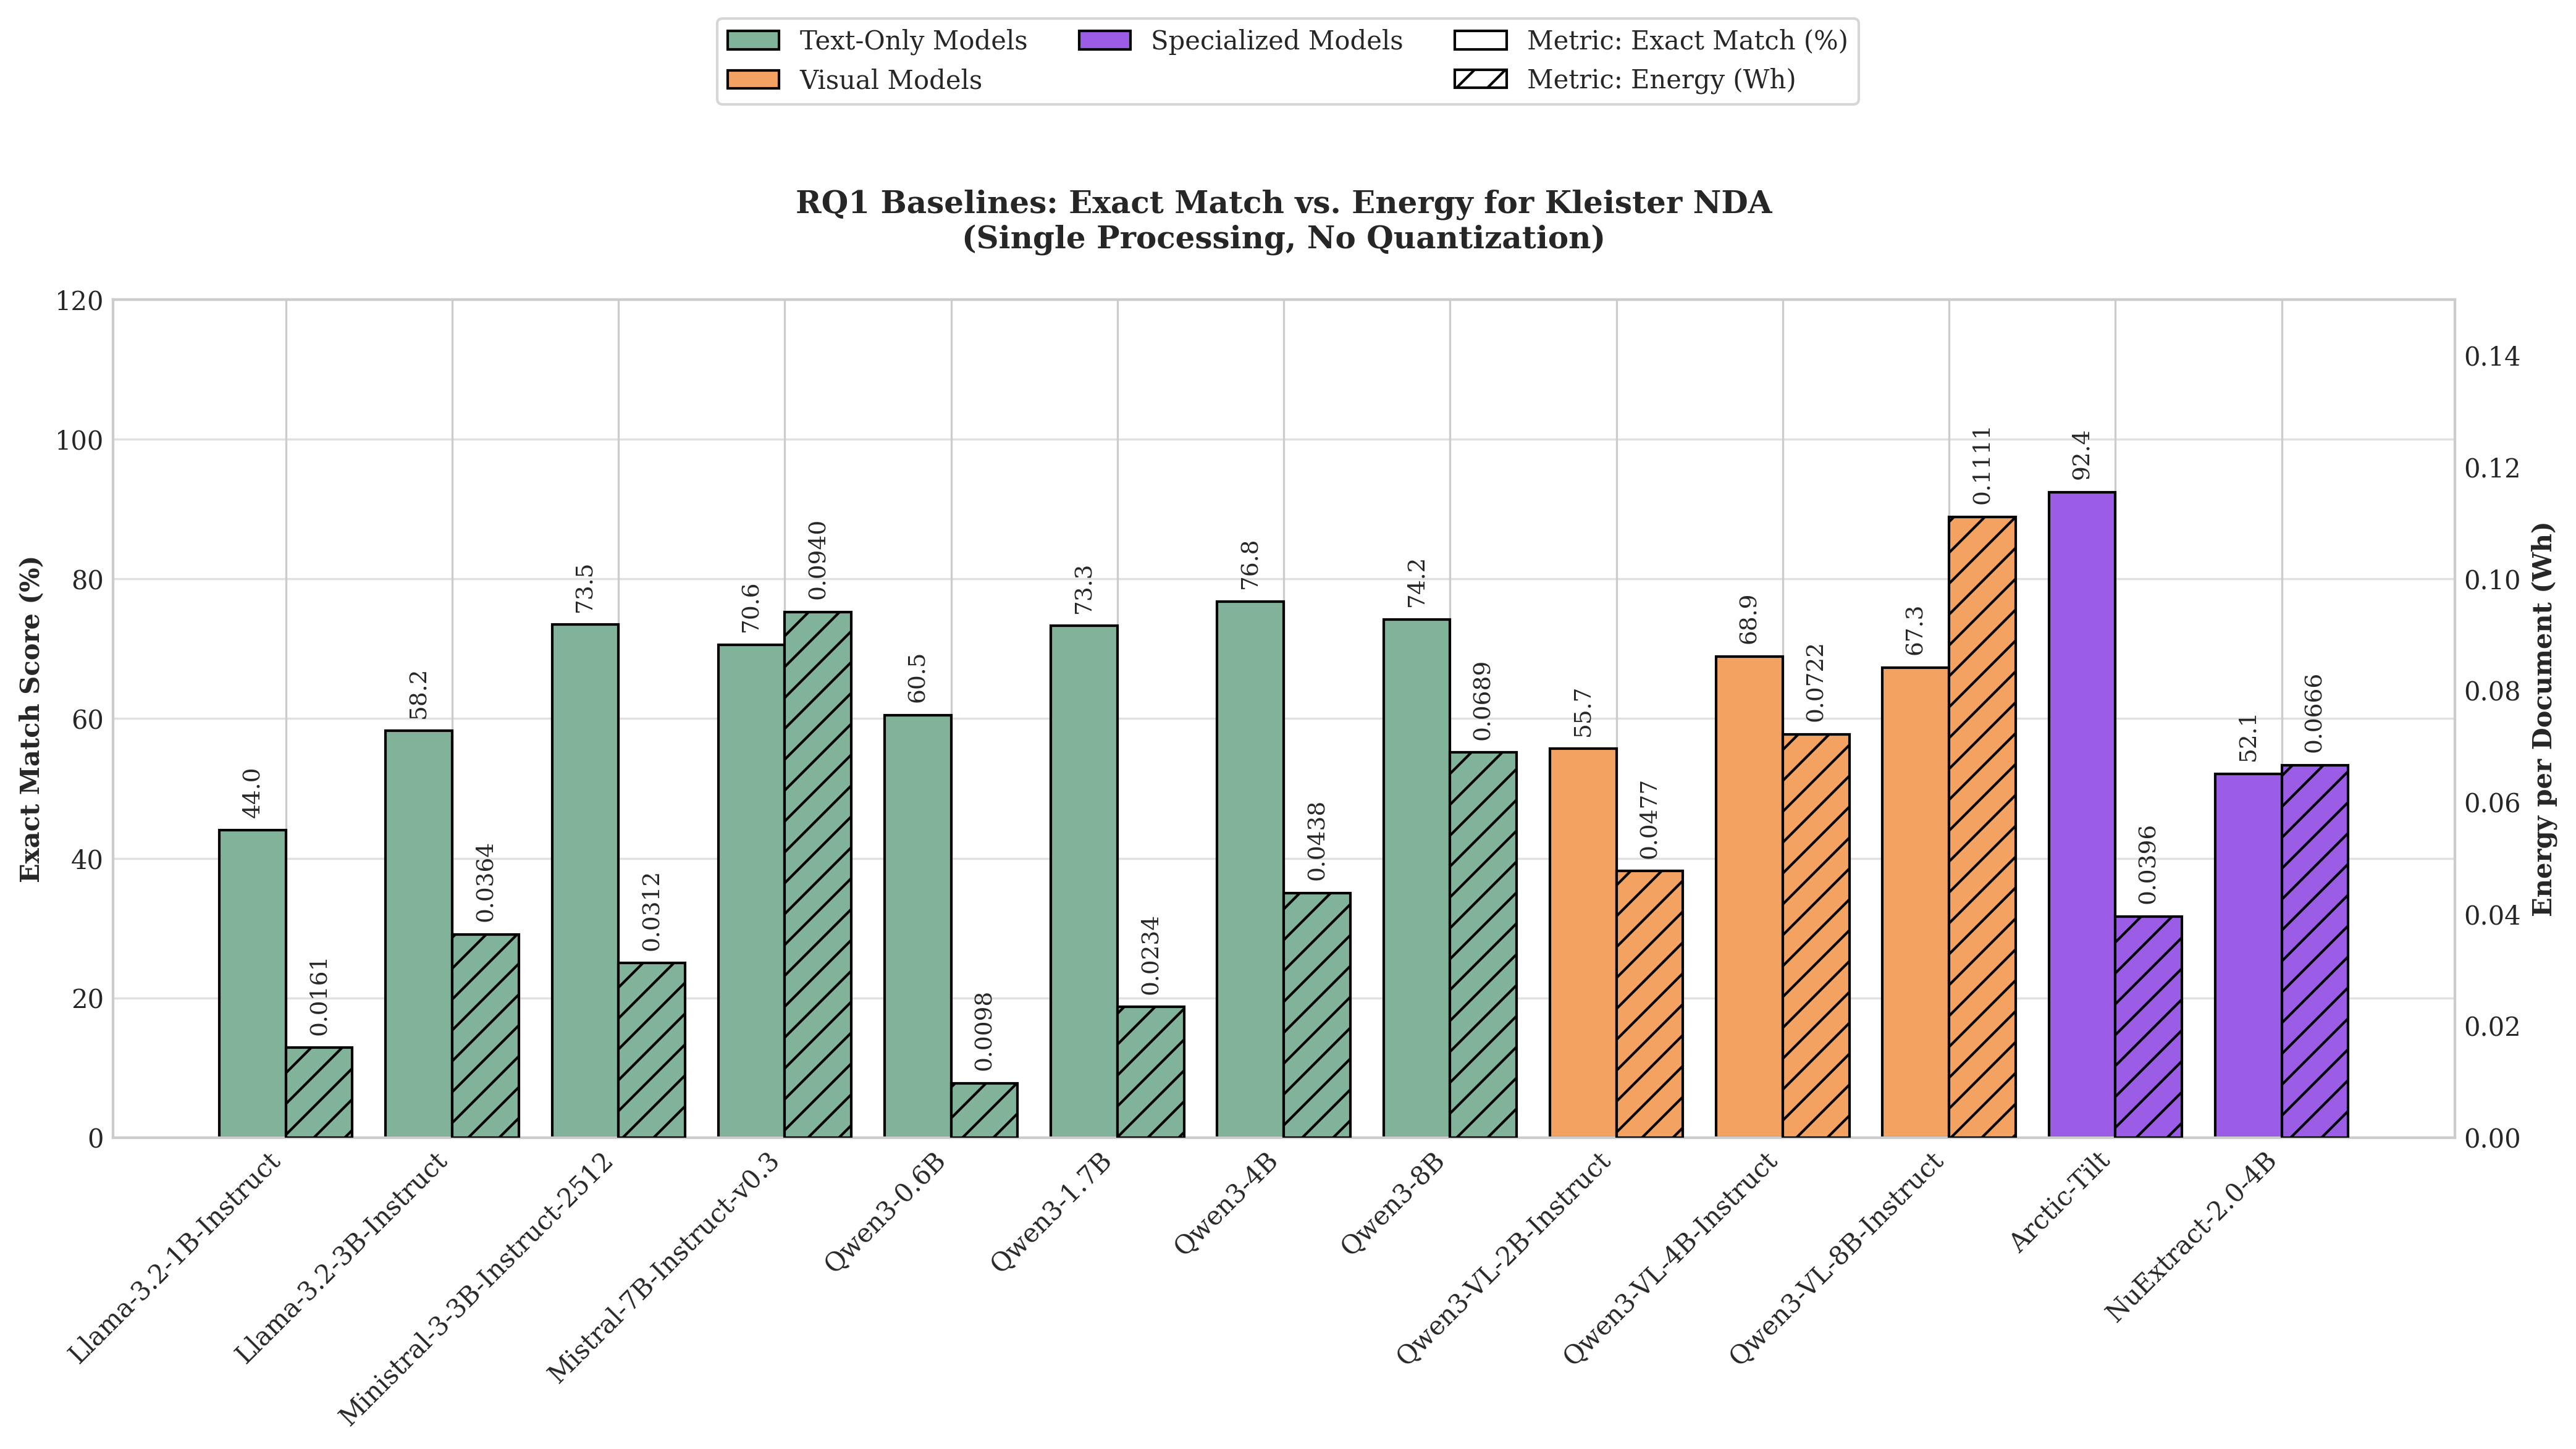

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# (Assuming df_all and TEST_SET_SIZES are defined earlier in your script)

# RQ1 Data Filtering
df_rq1 = df_all[
    (df_all['Batch_Size'] == 1) &
    (df_all['Quantized'] == False) &
    (
        (df_all['Modality'] == 'Vision') |
        ((df_all['Modality'] == 'Text-Only') & (df_all['Task'] == 'tesseract'))
    )
].copy()

# Calculate Energy per Document
df_rq1['Energy_per_Doc_Wh'] = df_rq1.apply(
    lambda row: row['Energy_Wh'] / TEST_SET_SIZES.get(row['Dataset'], 1), axis=1
)

datasets = ['VRDU', 'Kleister NDA']

# Helper function to assign colors and a sorting index
def get_color_and_sort_index(row):
    model_name = str(row['Model']).lower()
    if 'nuextract' in model_name or 'arctic-tilt' in model_name:
        return pd.Series(['#9b5de5', 3])  # Purple for specialized, sorted last
    elif row['Modality'] == 'Vision':
        return pd.Series(['#f4a261', 2])  # Orange for visual, sorted second
    elif row['Modality'] == 'Text-Only':
        return pd.Series(['#81b29a', 1])  # Green for text-only, sorted first
    return pd.Series(['gray', 4])

for dataset in datasets:
    df_ds = df_rq1[df_rq1['Dataset'] == dataset].copy()
    if df_ds.empty: continue

    # Apply the helper function to create Color and Sort columns
    df_ds[['Color', 'Category_Sort_Index']] = df_ds.apply(get_color_and_sort_index, axis=1)

    # --- SORTING FIX ---
    # Sort by Category Group first (1=Text, 2=Visual, 3=Specialized), then Alphabetically by Model
    df_ds = df_ds.sort_values(by=['Category_Sort_Index', 'Model'], ascending=[True, True])

    # Extract the sorted colors into a list for plotting
    bar_colors = df_ds['Color'].tolist()

    # Create a single plot with a dual Y-axis
    fig, ax1 = plt.subplots(figsize=(14, 7))
    ax2 = ax1.twinx()  # Create secondary Y-axis that shares the same X-axis

    # Enable grid on primary axis, push it behind the bars using zorder=0
    ax1.grid(True, axis='y', linestyle='-', alpha=0.6, zorder=0)
    # Explicitly turn off grid on secondary axis to prevent double grids
    ax2.grid(False)

    x = np.arange(len(df_ds['Model']))
    width = 0.4  # Width of the bars

    # Plot Exact Match (zorder=3 ensures bars render on top of the grid)
    rects_em = ax1.bar(x - width/2, df_ds['Exact_Match'], width, color=bar_colors, edgecolor='black', label='Exact Match', zorder=3)

    # Plot Energy (zorder=3 ensures bars render on top of the grid)
    rects_en = ax2.bar(x + width/2, df_ds['Energy_per_Doc_Wh'], width, color=bar_colors, edgecolor='black', hatch='//', label='Energy per Doc', zorder=3)

    # Annotate Exact Match bars (rotation=90)
    for rect in rects_em:
        height = rect.get_height()
        if height > 0:
            ax1.annotate(f'{height:.1f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 5), textcoords="offset points", ha='center', va='bottom',
                        fontsize=9, rotation=90, zorder=4)

    # Annotate Energy bars (rotation=90)
    for rect in rects_en:
        height = rect.get_height()
        if height > 0:
            ax2.annotate(f'{height:.4f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 5), textcoords="offset points", ha='center', va='bottom',
                        fontsize=9, rotation=90, zorder=4)

    # Formatting Left Axis (Exact Match)
    ax1.set_ylabel('Exact Match Score (%)', fontweight='bold')
    ax1.set_ylim(0, 120)
    ax1.set_xticks(x)
    ax1.set_xticklabels(df_ds['Model'], rotation=45, ha='right')

    # Formatting Right Axis (Energy)
    ax2.set_ylabel('Energy per Document (Wh)', fontweight='bold')
    ax2.set_ylim(0, df_ds['Energy_per_Doc_Wh'].max() * 1.35)

    # Custom legend for BOTH color mappings and metric textures
    legend_elements = [
        # Model categories
        Patch(facecolor='#81b29a', edgecolor='black', label='Text-Only Models'),
        Patch(facecolor='#f4a261', edgecolor='black', label='Visual Models'),
        Patch(facecolor='#9b5de5', edgecolor='black', label='Specialized Models'),
        # Blank spacer for layout
        Patch(facecolor='none', edgecolor='none', label=' '),
        # Metric types (Solid vs Hatched)
        Patch(facecolor='white', edgecolor='black', label='Metric: Exact Match (%)'),
        Patch(facecolor='white', edgecolor='black', hatch='//', label='Metric: Energy (Wh)')
    ]

    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=3, frameon=True)

    plt.title(f'RQ1 Baselines: Exact Match vs. Energy for {dataset}\n(Single Processing, No Quantization)', fontweight='bold', pad=20)

    plt.tight_layout()
    plt.savefig(f'rq1_baselines_dual_{dataset.lower().replace(" ", "_")}.pdf', bbox_inches='tight')
    plt.show()

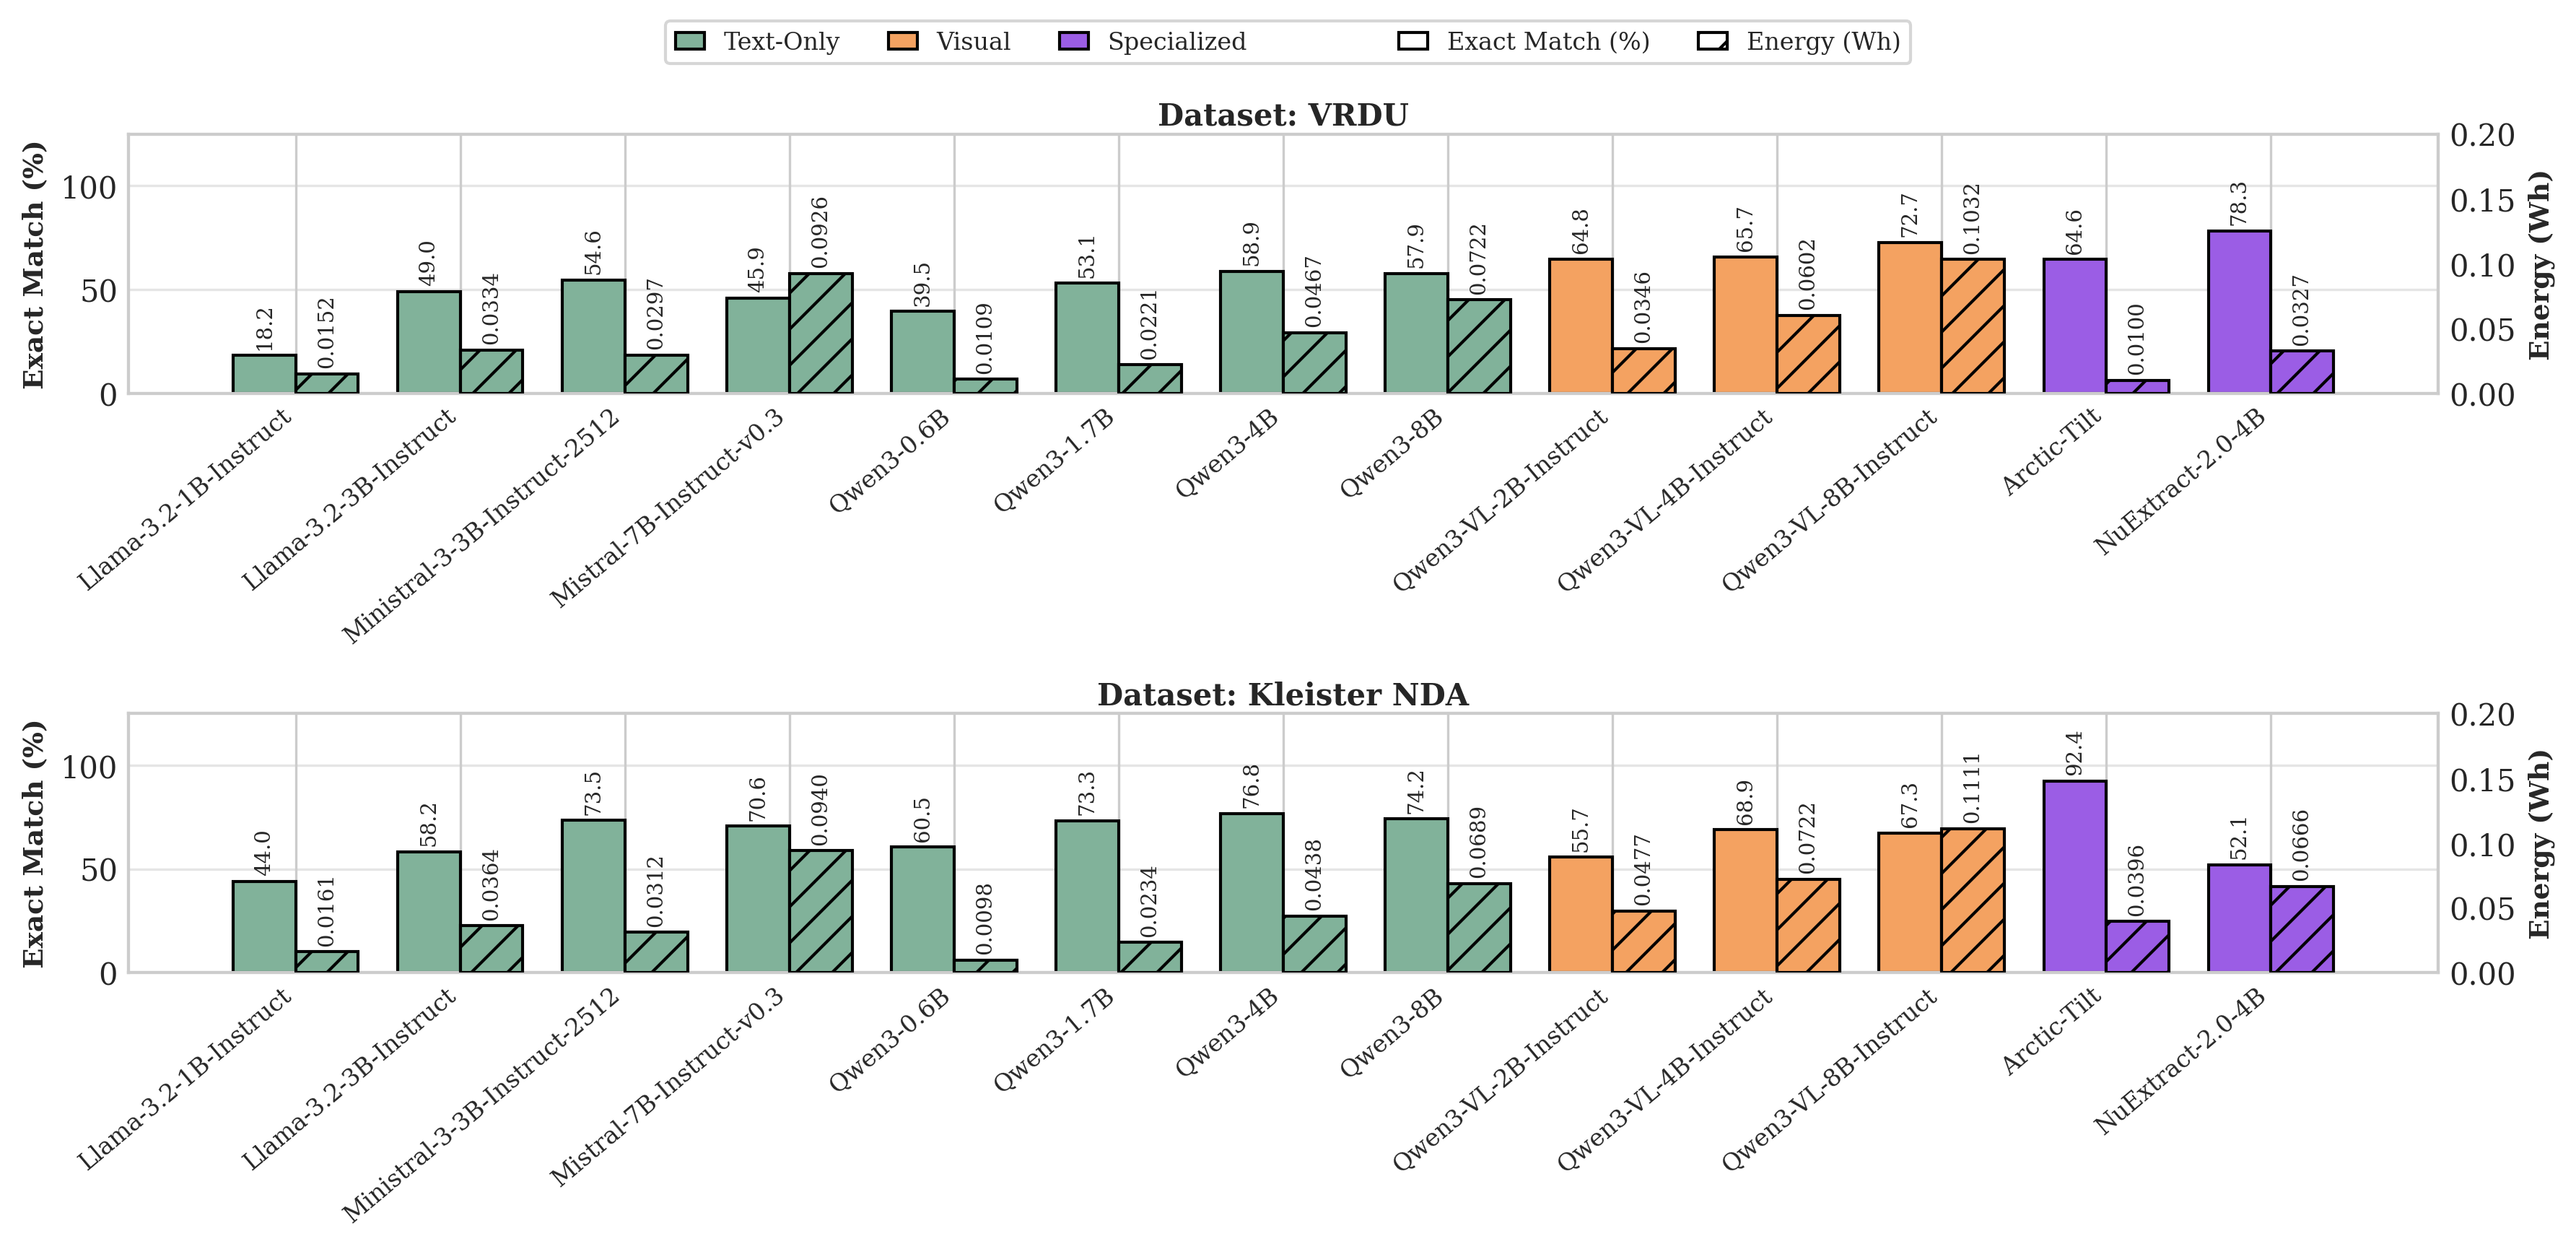

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# (Assuming df_rq1 and helper function get_color_and_sort_index are defined)

datasets = ['VRDU', 'Kleister NDA']

# Reduced height significantly (12 width x 5.5 height total)
fig, axes = plt.subplots(2, 1, figsize=(12, 5.5))
fig.subplots_adjust(hspace=0.25) # Tightened spacing between subplots

legend_elements = [
    Patch(facecolor='#81b29a', edgecolor='black', label='Text-Only'),
    Patch(facecolor='#f4a261', edgecolor='black', label='Visual'),
    Patch(facecolor='#9b5de5', edgecolor='black', label='Specialized'),
    Patch(facecolor='white', edgecolor='none', label=' '),
    Patch(facecolor='white', edgecolor='black', label='Exact Match (%)'),
    Patch(facecolor='white', edgecolor='black', hatch='//', label='Energy (Wh)')
]

for idx, dataset in enumerate(datasets):
    ax1 = axes[idx]
    df_ds = df_rq1[df_rq1['Dataset'] == dataset].copy()
    if df_ds.empty: continue

    df_ds[['Color', 'Category_Sort_Index']] = df_ds.apply(get_color_and_sort_index, axis=1)
    df_ds = df_ds.sort_values(by=['Category_Sort_Index', 'Model'], ascending=[True, True])
    bar_colors = df_ds['Color'].tolist()

    ax2 = ax1.twinx()
    ax1.grid(True, axis='y', linestyle='-', alpha=0.5, zorder=0)
    ax2.grid(False)

    x = np.arange(len(df_ds['Model']))
    width = 0.38

    rects_em = ax1.bar(x - width/2, df_ds['Exact_Match'], width, color=bar_colors, edgecolor='black', zorder=3)
    rects_en = ax2.bar(x + width/2, df_ds['Energy_per_Doc_Wh'], width, color=bar_colors, edgecolor='black', hatch='//', zorder=3)

    # Compact Annotations (smaller font size to fit shorter bars)
    for rect in rects_em:
        height = rect.get_height()
        if height > 0:
            ax1.annotate(f'{height:.1f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 2), textcoords="offset points", ha='center', va='bottom',
                        fontsize=7, rotation=90, zorder=4)

    for rect in rects_en:
        height = rect.get_height()
        if height > 0:
            ax2.annotate(f'{height:.4f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 2), textcoords="offset points", ha='center', va='bottom',
                        fontsize=7, rotation=90, zorder=4)

    # Formatting Y-axes concisely
    ax1.set_ylabel('Exact Match (%)', fontweight='bold', fontsize=9)
    ax1.set_ylim(0, 125) # Slightly padded top to accommodate annotations in less height
    ax1.set_xticks(x)
    ax1.set_xticklabels(df_ds['Model'], rotation=40, ha='right', fontsize=8)

    ax2.set_ylabel('Energy (Wh)', fontweight='bold', fontsize=9)
    #ax2.set_ylim(0, df_ds['Energy_per_Doc_Wh'].max() * 1.4)
    ax2.set_ylim(0, 0.2)

    # Minimalist subplot titles
    ax1.set_title(f'Dataset: {dataset}', fontweight='bold', fontsize=10, pad=3)

# Compact upper center legend
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.05),
           ncol=6, frameon=True, fontsize=8, handlelength=1.2)

plt.tight_layout()
plt.savefig('rq1_baselines_compact.pdf', bbox_inches='tight')
plt.show()